In [2]:
import os, random
from pathlib import Path

from PIL import Image
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
IMAGE_SIZE = 256

In [4]:
BASE_DIR = Path(r"/home/prolex/prokhor_grasp_labeller/dataset")

In [5]:
tested_iteration = BASE_DIR / random.sample(os.listdir(BASE_DIR), 1)[0]
camera_meta_path = tested_iteration / "opentouch/digit360/index/camera/camera.csv"
# phase_data_path = tested_iteration / "grasp/grasp_phases.csv"
frames_path = tested_iteration / "opentouch/digit360/index/camera/frames"

In [6]:
frames_meta = pd.read_csv(camera_meta_path)
# phase_data = pd.read_csv(phase_data_path)

In [7]:
last_frames_names = [frames_path / filename for filename in frames_meta.sort_values(by="time_perf", axis=0)["filename"].iloc[-16:]]

In [8]:
frames_arr = np.stack([
    np.asarray(Image.open(frames_path / frame_path).convert("RGB"))
    for frame_path in last_frames_names
], dtype=np.uint8)

In [9]:
img = np.mean(frames_arr, axis=0).astype(np.uint8)
img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

In [10]:
img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_AREA)

In [11]:
img = img.astype(np.float32) / 255.0
img = np.transpose(img, (2, 0, 1))

In [12]:
# Should be set in config
top = (256 - 224) // 2   # 16
left = (256 - 224) // 2  # 16

In [22]:
img.shape

(3, 256, 256)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

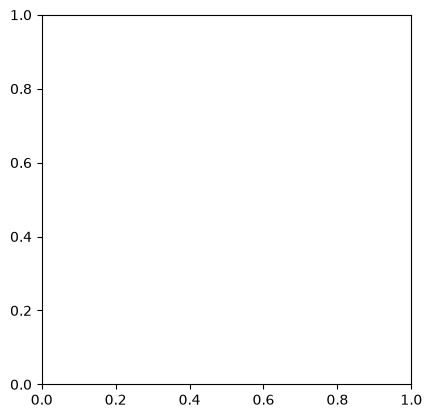

In [23]:
plt.imshow((np.transpose(img[:, 16:240, 16:240]), (1, 2, 0)))
plt.axis("off")
plt.show()